In [ ]:
# 1. Install zstd, pciutils, lshw (required for Ollama GPU detection) and Ollama binary
!apt-get update && apt-get install -y zstd pciutils lshw
!curl -fsSL https://ollama.com/install.sh | sh

# 2. Start the Ollama background daemon with proper detachment
import subprocess
import time
import httpx

print("Starting Ollama daemon in background (detached session)...")
!pkill -9 ollama 2>/dev/null || true
time.sleep(1)

ollama_log = open("ollama.log", "w")
subprocess.Popen(
    ["ollama", "serve"],
    stdout=ollama_log,
    stderr=subprocess.STDOUT,
    start_new_session=True
)

# Wait for Ollama to become ready
print("Waiting for Ollama to become ready on port 11434...")
for attempt in range(15):
    try:
        r = httpx.get("http://localhost:11434", timeout=1.0)
        if r.status_code == 200:
            print("✅ Ollama is UP and responding on port 11434!")
            break
    except Exception:
        pass
    time.sleep(1)
else:
    print("❌ Ollama failed to start. Contents of ollama.log:")
    with open("ollama.log") as f:
        print(f.read())
    raise RuntimeError("Ollama could not start.")


In [ ]:
# Pull the 8B model (takes ~2-3 minutes to download ~4.7 GB)
!ollama pull llama2:7b

# Optional: verify model is installed
!ollama list



NAME           ID              SIZE      MODIFIED               
llama3.1:8b    46e0c10c039e    4.9 GB    Less than a second ago    


In [5]:
!git clone https://github.com/Hemant-Shashikant-Yadav/LLM-Hallucination.git

Cloning into 'LLM-Hallucination'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 168 (delta 39), reused 152 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 731.29 KiB | 24.38 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [7]:
ls

LLM-Hallucination/  sample_data/


In [8]:
cd LLM-Hallucination

/content/LLM-Hallucination


In [9]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95

In [ ]:
# Verify GPU is detected and check current VRAM allocation
!nvidia-smi
print("\n--- Verifying Ollama API ---")
!curl http://localhost:11434


In [ ]:
import os
import subprocess
import time
import httpx

# 1. Verify working directory contains 'app'
if not os.path.exists("app"):
    raise FileNotFoundError(
        f"Cannot find 'app' directory in {os.getcwd()}! "
        f"Make sure to %cd into your project folder first."
    )

# 2. Configure Hardware Acceleration via Environment Variables
# Ensures TinyLlama (Surrogate) and DeBERTa (NLI) load onto T4 GPU in FP16
os.environ["DID_DEVICE"] = "cuda"
os.environ["DID_USE_FP16"] = "true"

# 3. Verify Ollama is actually reachable
try:
    ollama_check = httpx.get("http://localhost:11434", timeout=3.0)
    print("✓ Ollama daemon is reachable:", ollama_check.text.strip())
except Exception as e:
    raise RuntimeError("Ollama is not running on http://localhost:11434. Please re-run Cell 0!")

# 4. Start FastAPI with output redirected to 'server.log'
print("\nStarting Defense-in-Depth FastAPI server (redirecting logs to server.log)...")
log_file = open("server.log", "w")
server_proc = subprocess.Popen(
    ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

# 5. Wait for /api/v1/health to respond
print("Waiting for server and Hugging Face models to load onto GPU...")
server_ready = False

for attempt in range(60):  # Wait up to 120 seconds
    if server_proc.poll() is not None:
        print(f"\n❌ Server process terminated unexpectedly with exit code {server_proc.poll()}!")
        break

    try:
        res = httpx.get("http://localhost:8000/api/v1/health", timeout=3.0)
        if res.status_code == 200:
            print("\n✅ Server is UP and healthy on GPU!")
            print(res.json())
            server_ready = True
            break
    except Exception:
        pass

    time.sleep(2)
    if attempt % 5 == 0 and attempt > 0:
        print(f"Still initializing... ({attempt * 2}s elapsed)")

# 6. If it failed, print the exact crash log
if not server_ready:
    log_file.flush()
    print("\n--- SERVER.LOG (CRASH TRACEBACK) ---")
    with open("server.log", "r") as f:
        print(f.read())
    raise RuntimeError("Server failed to initialize. See server.log above for details.")


In [ ]:
!rm -f evaluation/results_truthfulqa.csv evaluation/results_gsm8k.csv


In [ ]:
# Cell 5: Run benchmarks
!python -m evaluation.benchmark_runner



✅ All 8 thesis graphs generated successfully in the 'evaluation/plots/' directory!
========== CORE OBJECTIVES ==========

--- ACCURACY (Objective 4) ---


2026-10-07 05:59:06.995 | INFO     | __main__:main:271 - Loaded 90 total evaluation rows.
2026-10-07 05:59:07.319 | INFO     | __main__:plot_accuracy:92 - Saved: D:\Coding\Project\LLM-Hallucination\evaluation\plots\thesis_accuracy_comparison.png
2026-10-07 05:59:07.538 | INFO     | __main__:plot_entropy_distribution:118 - Saved: D:\Coding\Project\LLM-Hallucination\evaluation\plots\thesis_entropy_distribution.png
2026-10-07 05:59:07.740 | INFO     | __main__:plot_triage_routing:145 - Saved: D:\Coding\Project\LLM-Hallucination\evaluation\plots\thesis_routing_piecharts.png
2026-10-07 05:59:08.111 | INFO     | __main__:plot_latency_distribution:168 - Saved: D:\Coding\Project\LLM-Hallucination\evaluation\plots\thesis_latency_boxplot.png
2026-10-07 05:59:08.301 | INFO     | __main__:plot_token_overhead:195 - Saved: D:\Coding\Project\LLM-Hallucination\evaluation\plots\thesis_token_overhead.png
2026-10-07 05:59:08.486 | INFO     | __main__:plot_layer_invocations:221 - Saved: D:\Coding\Project\

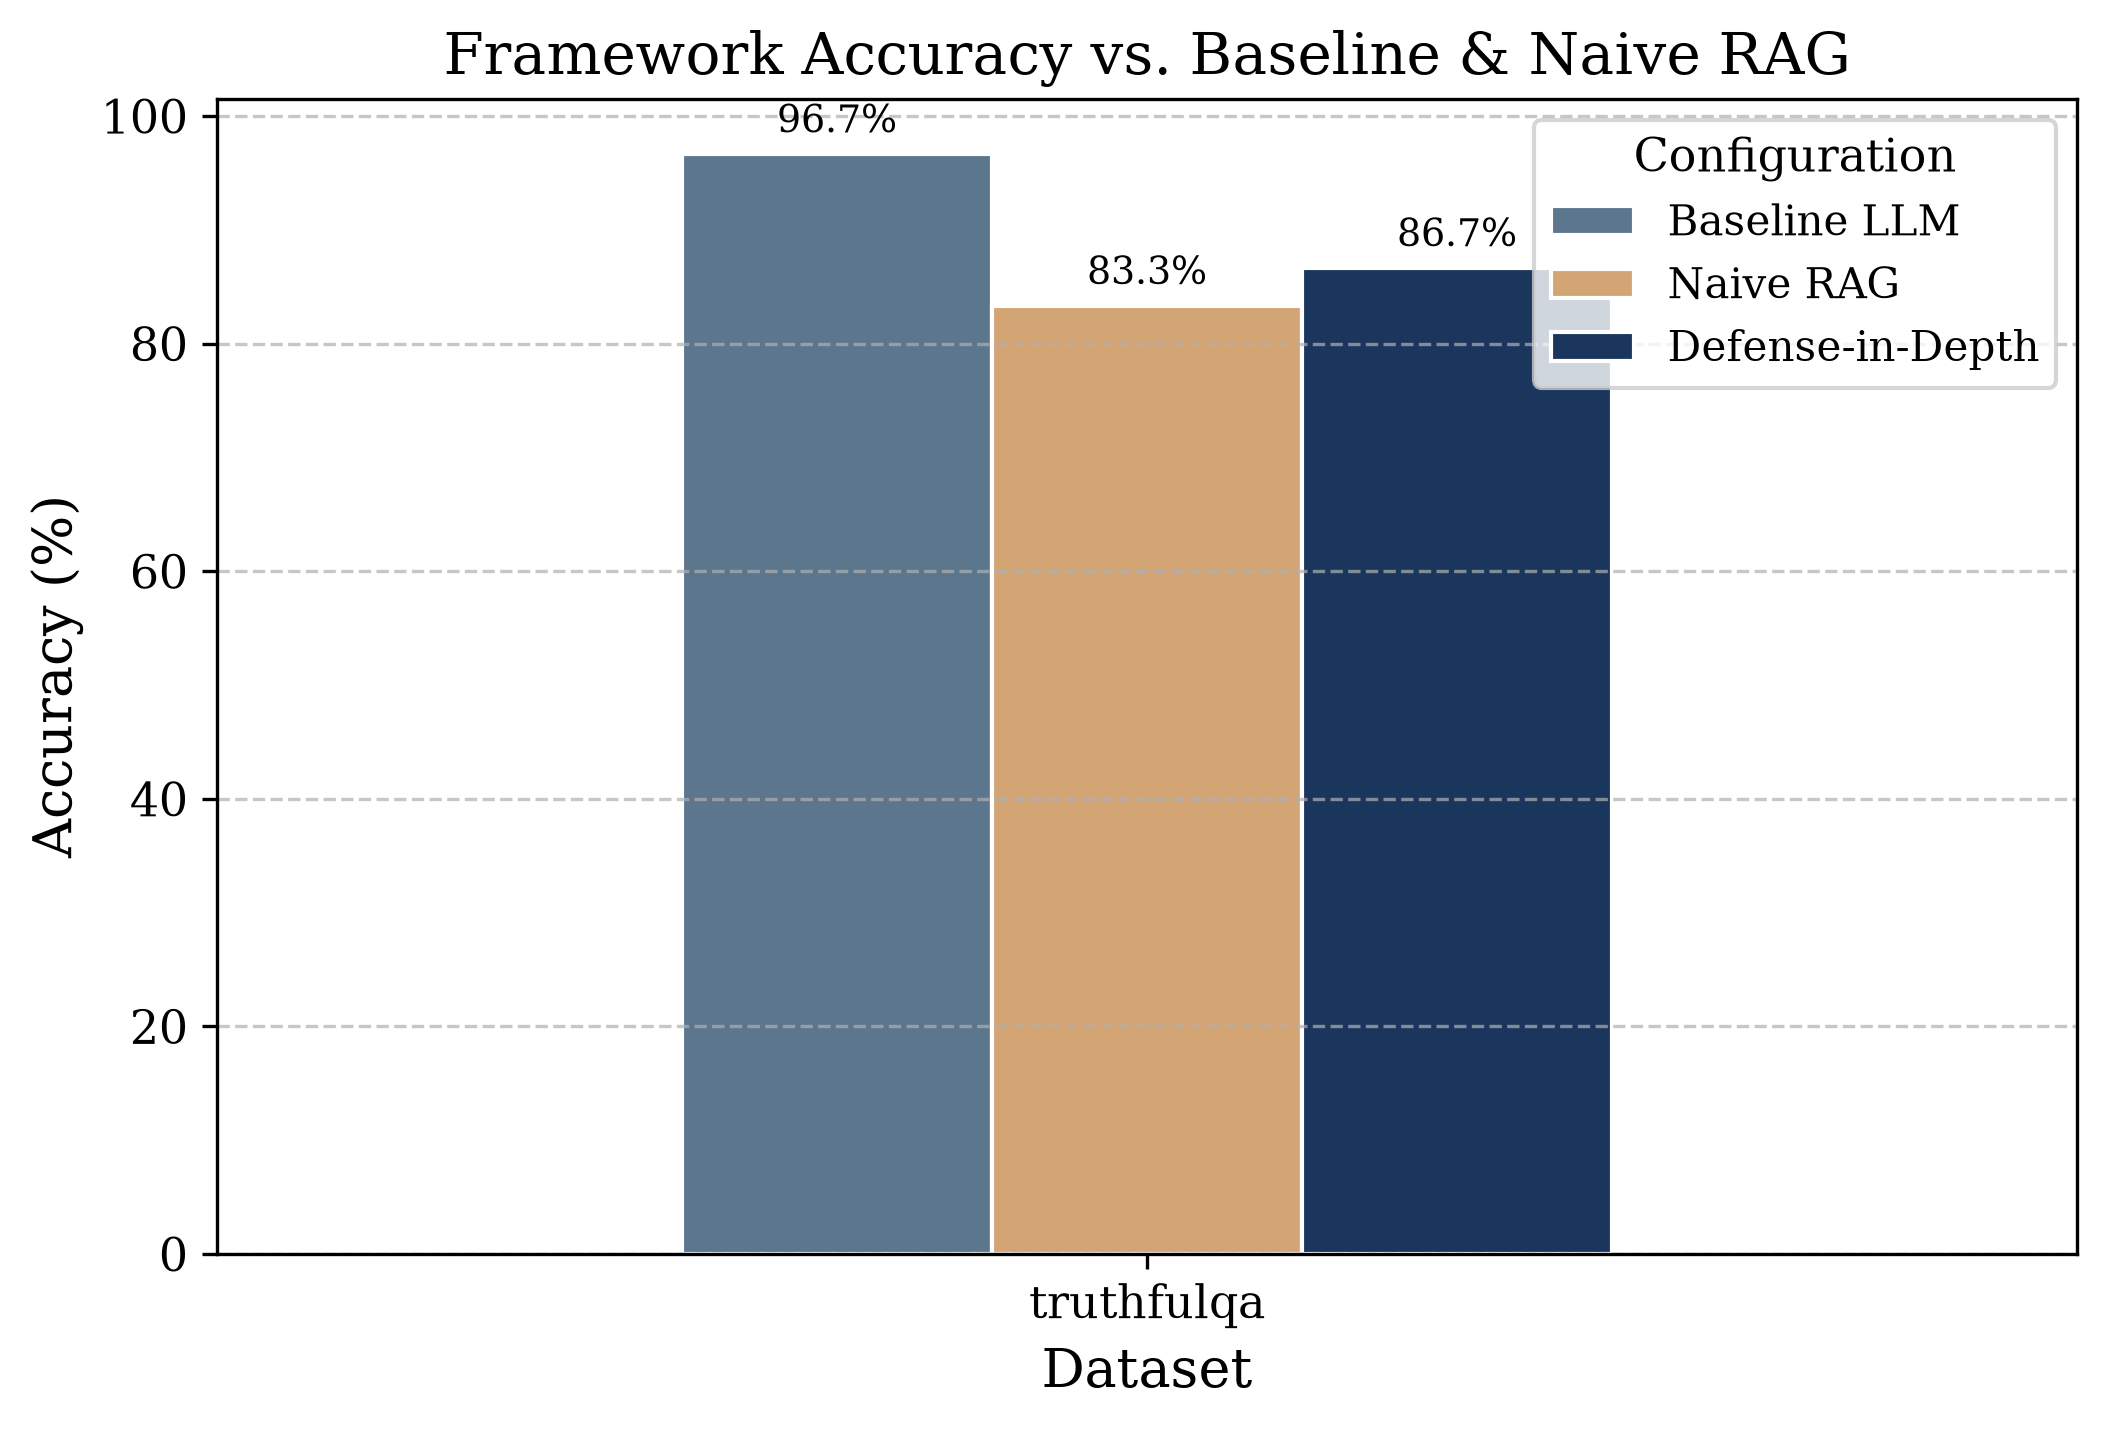


--- UNCERTAINTY PROBE (Objective 1) ---


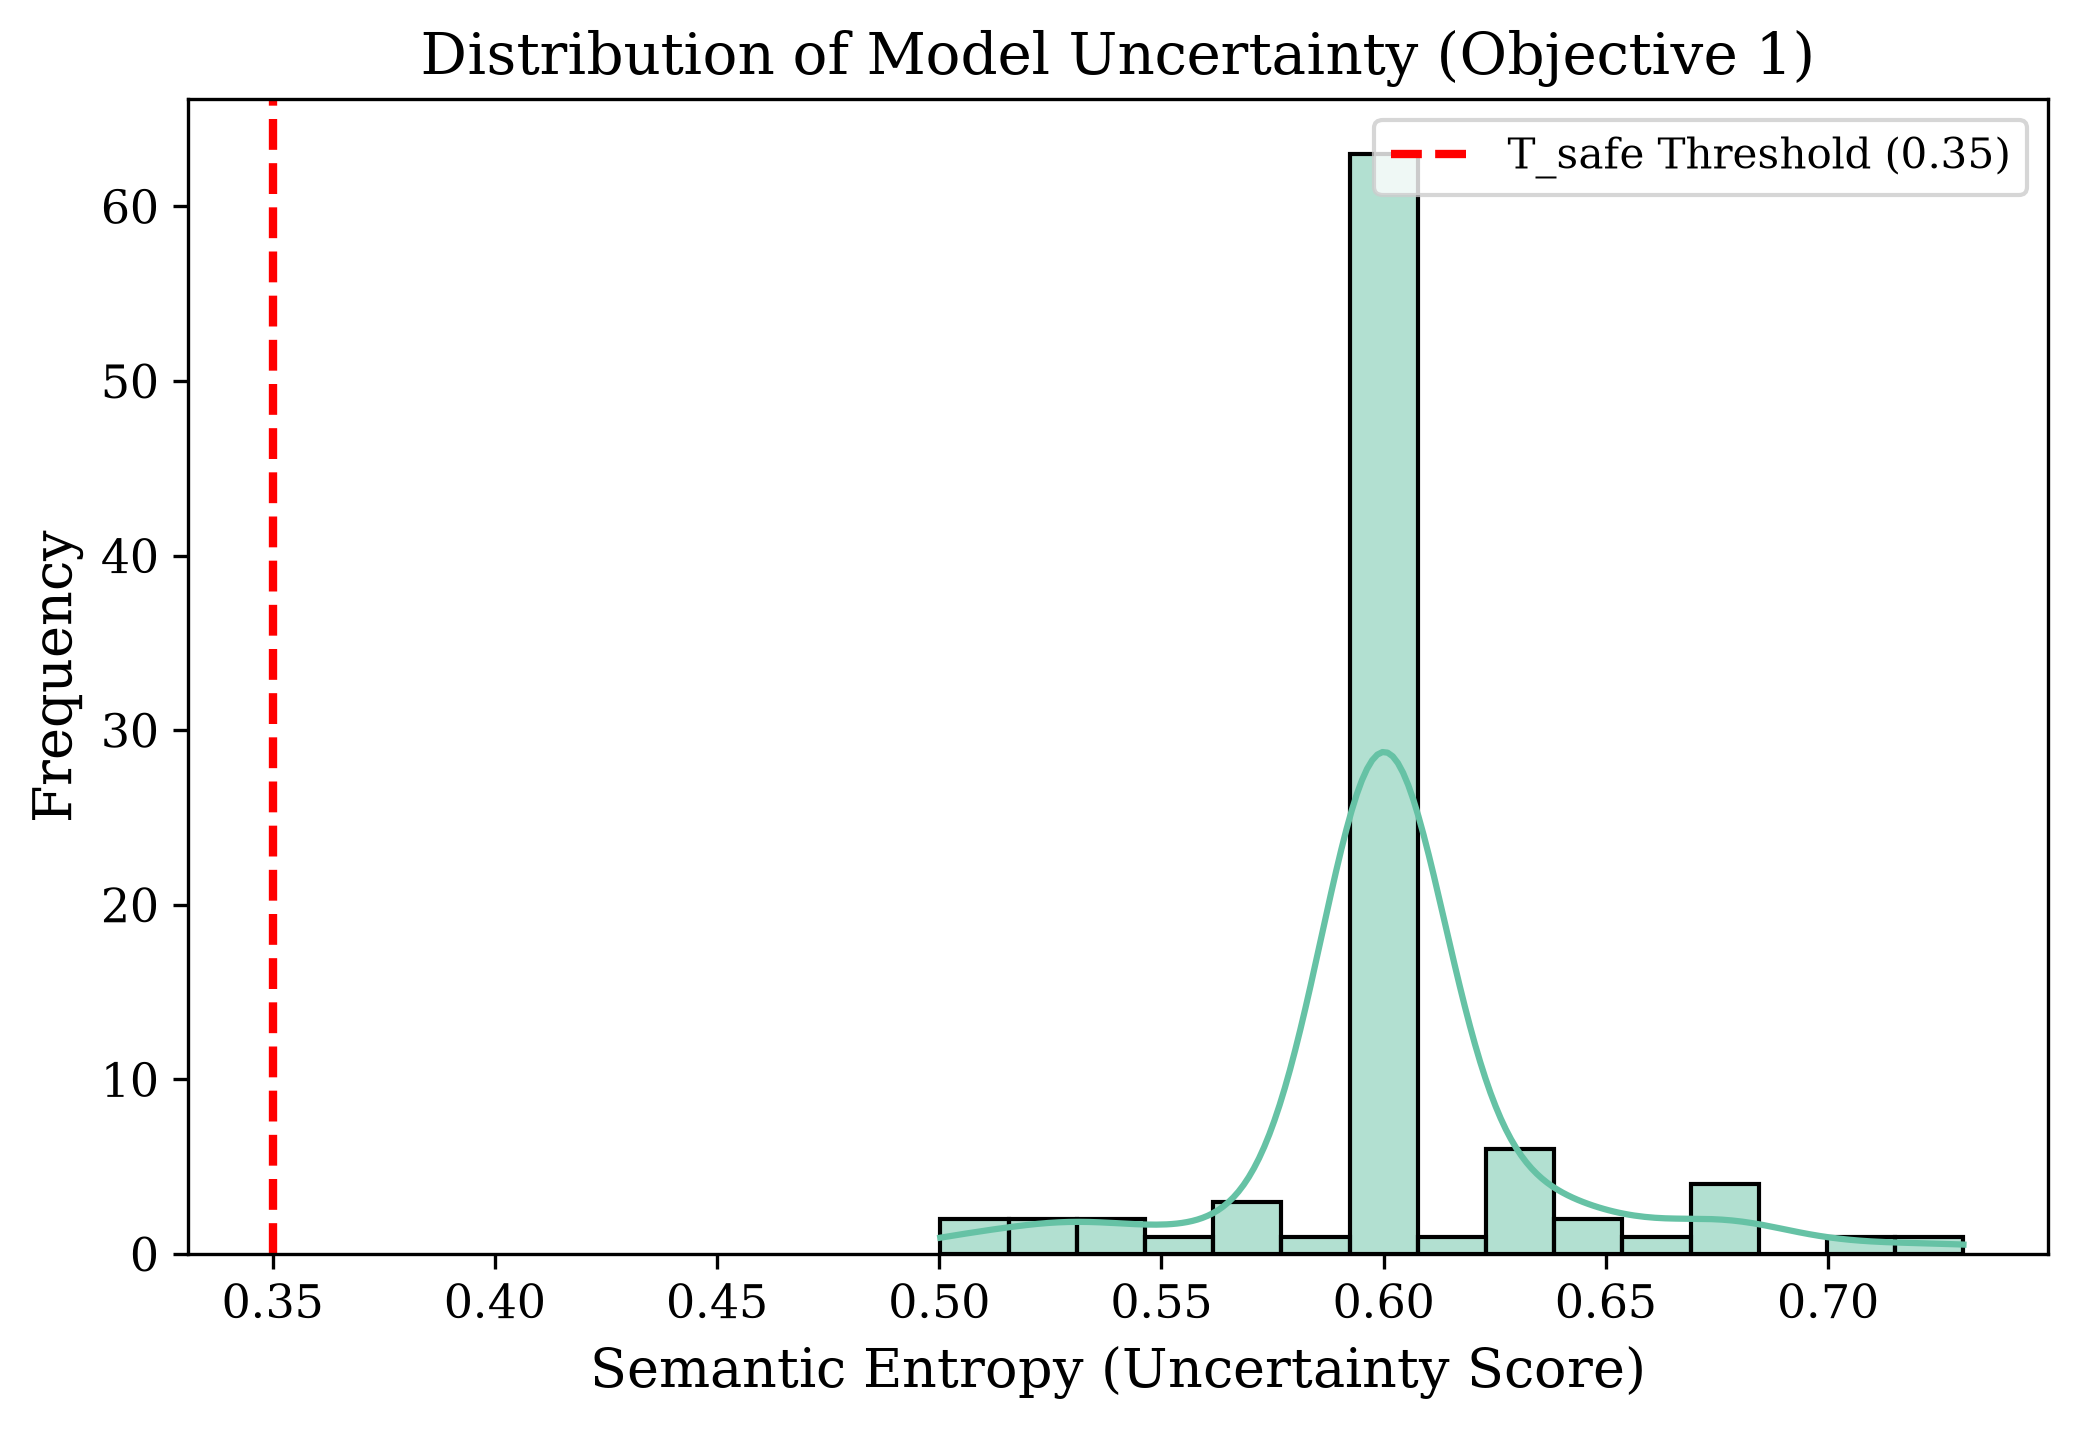


--- TRIAGE ROUTING (Objective 2) ---


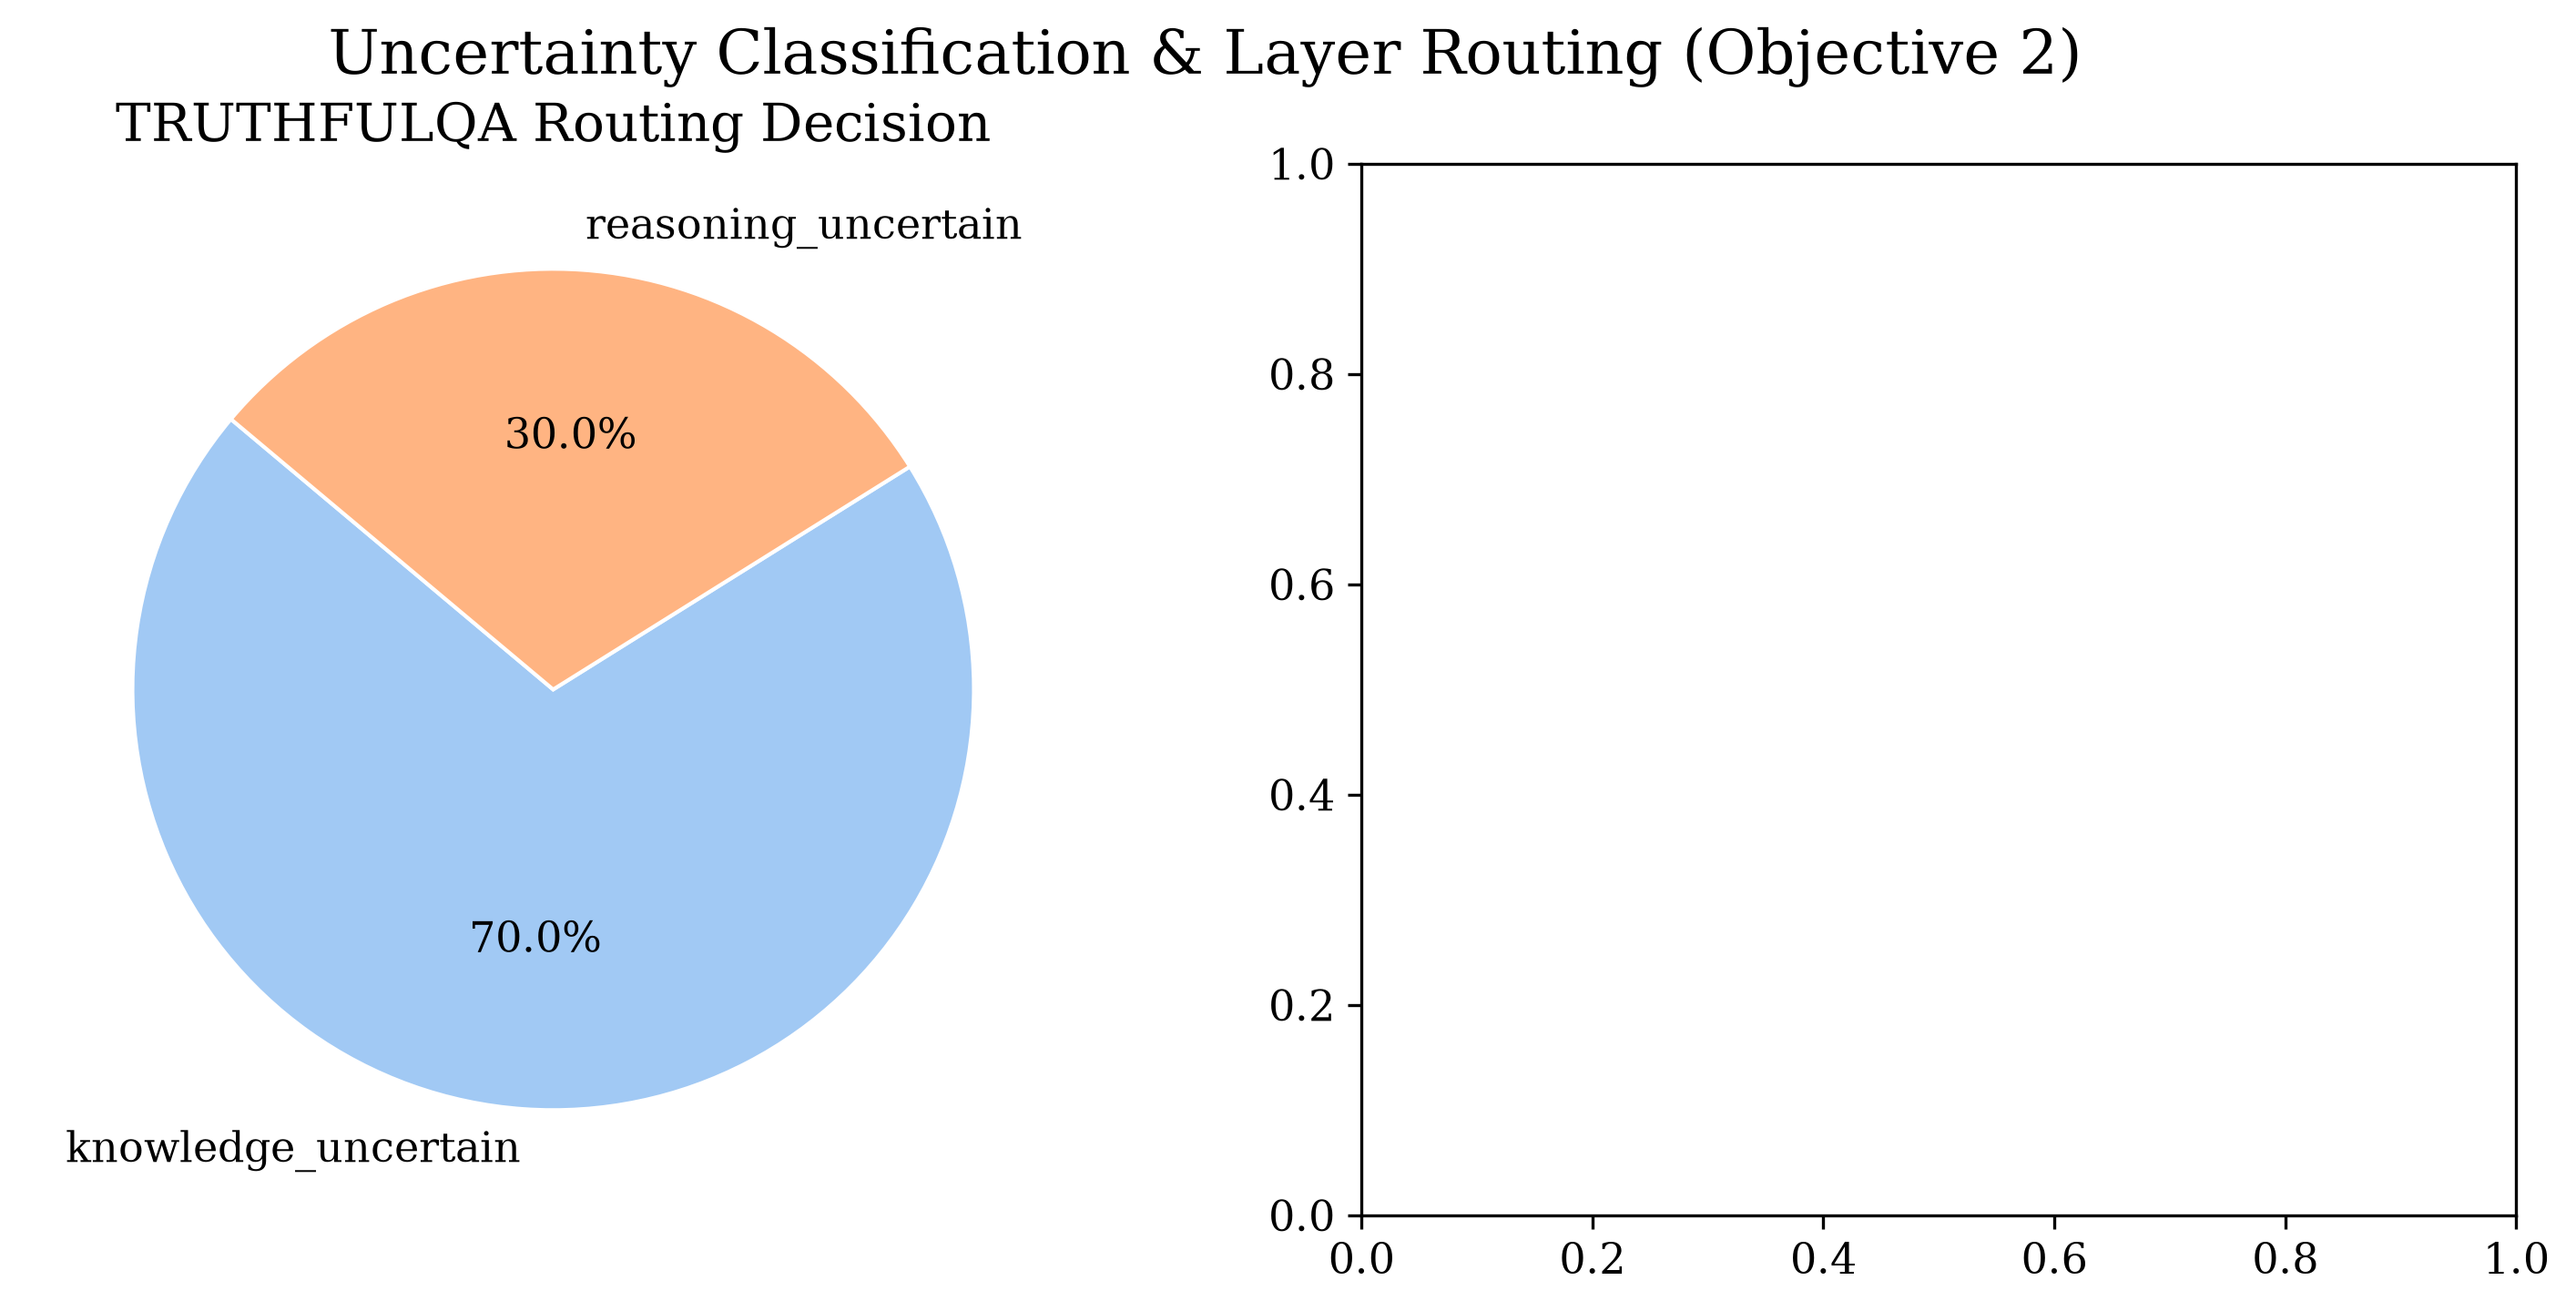


--- COMPUTATIONAL COST (Objective 4) ---


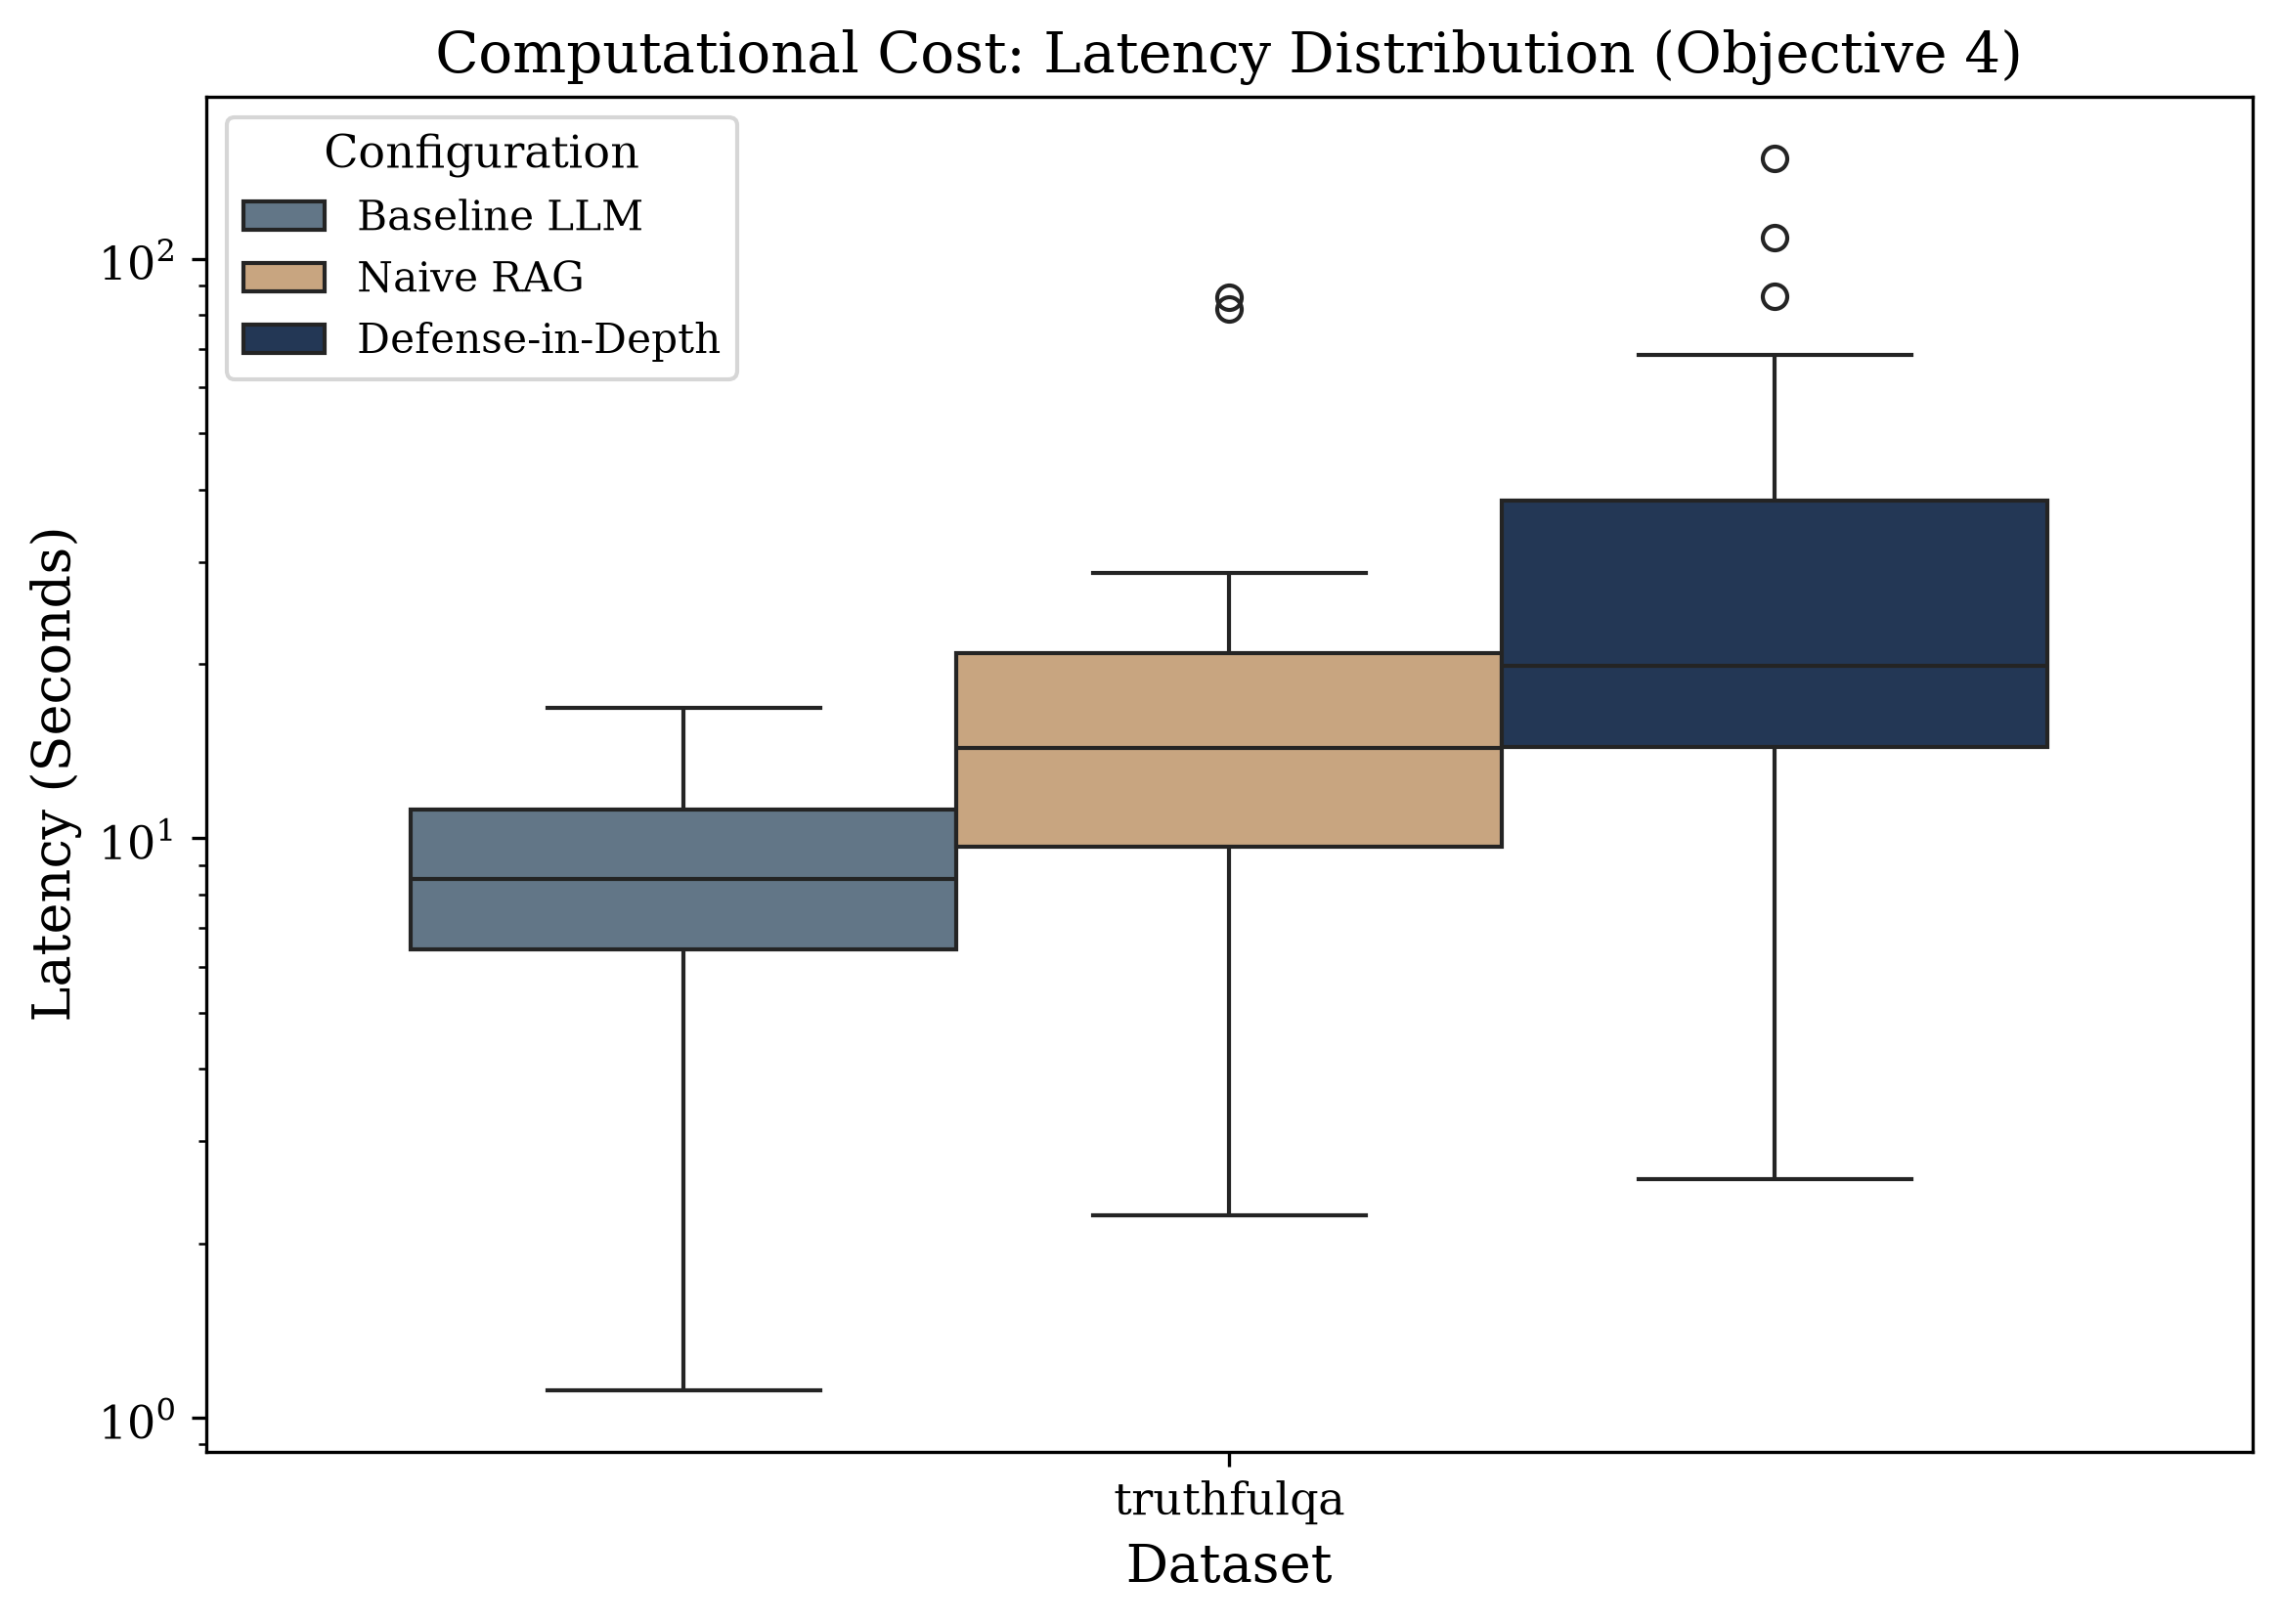


========== DEEP ANALYSIS ==========

--- TOKEN EFFICIENCY ---


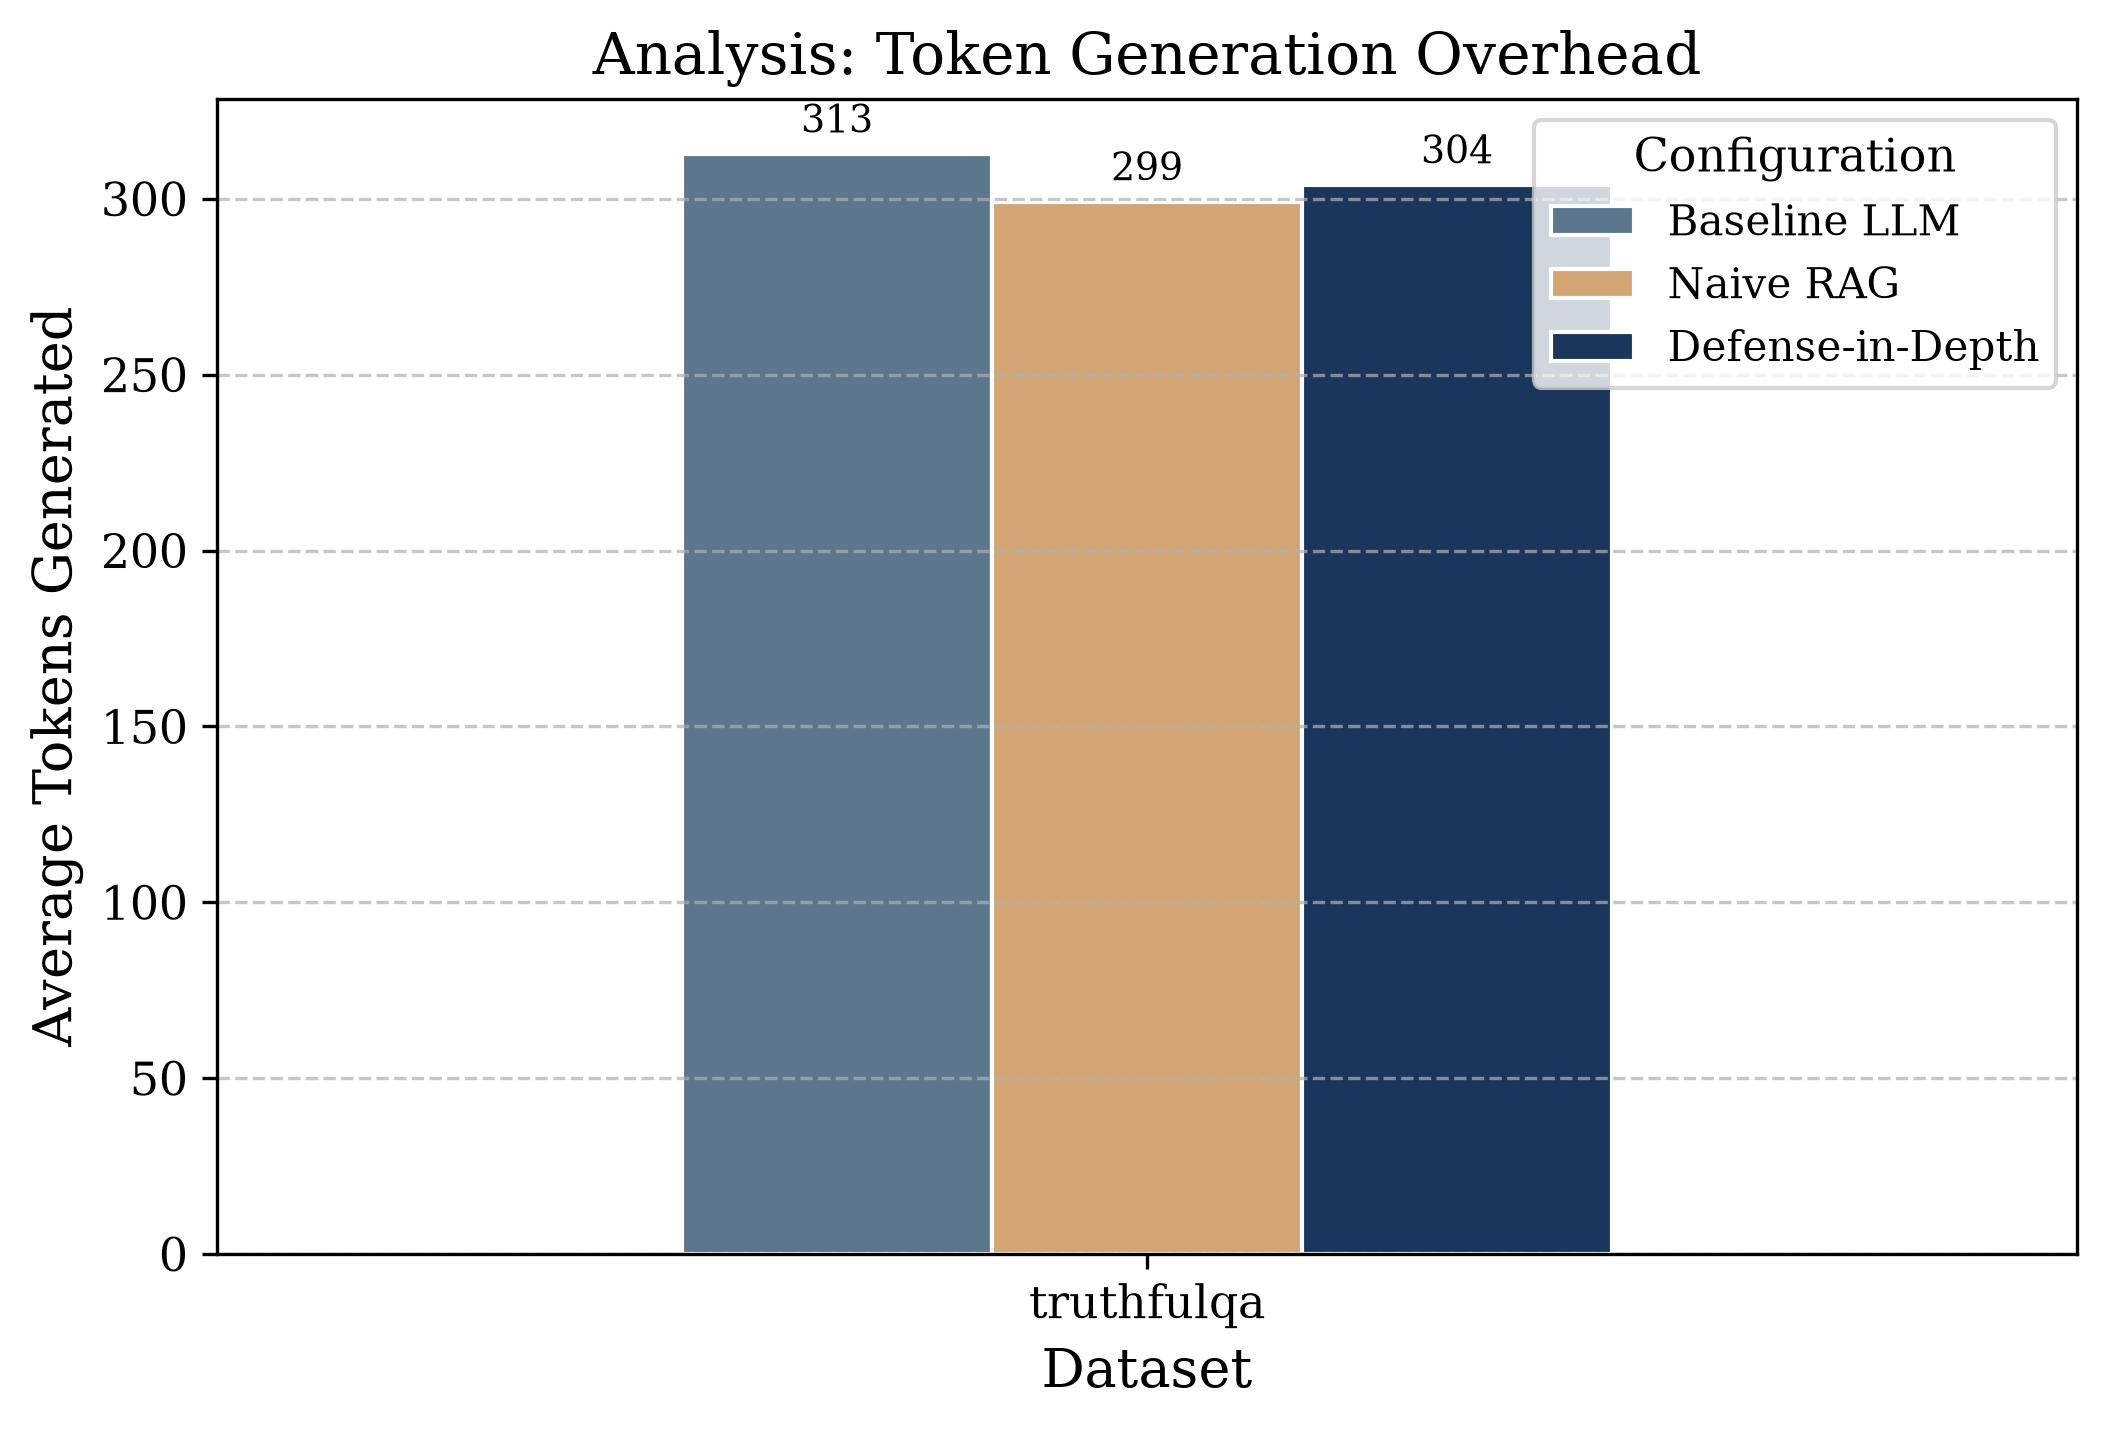


--- LAYER INVOCATION FLOW ---


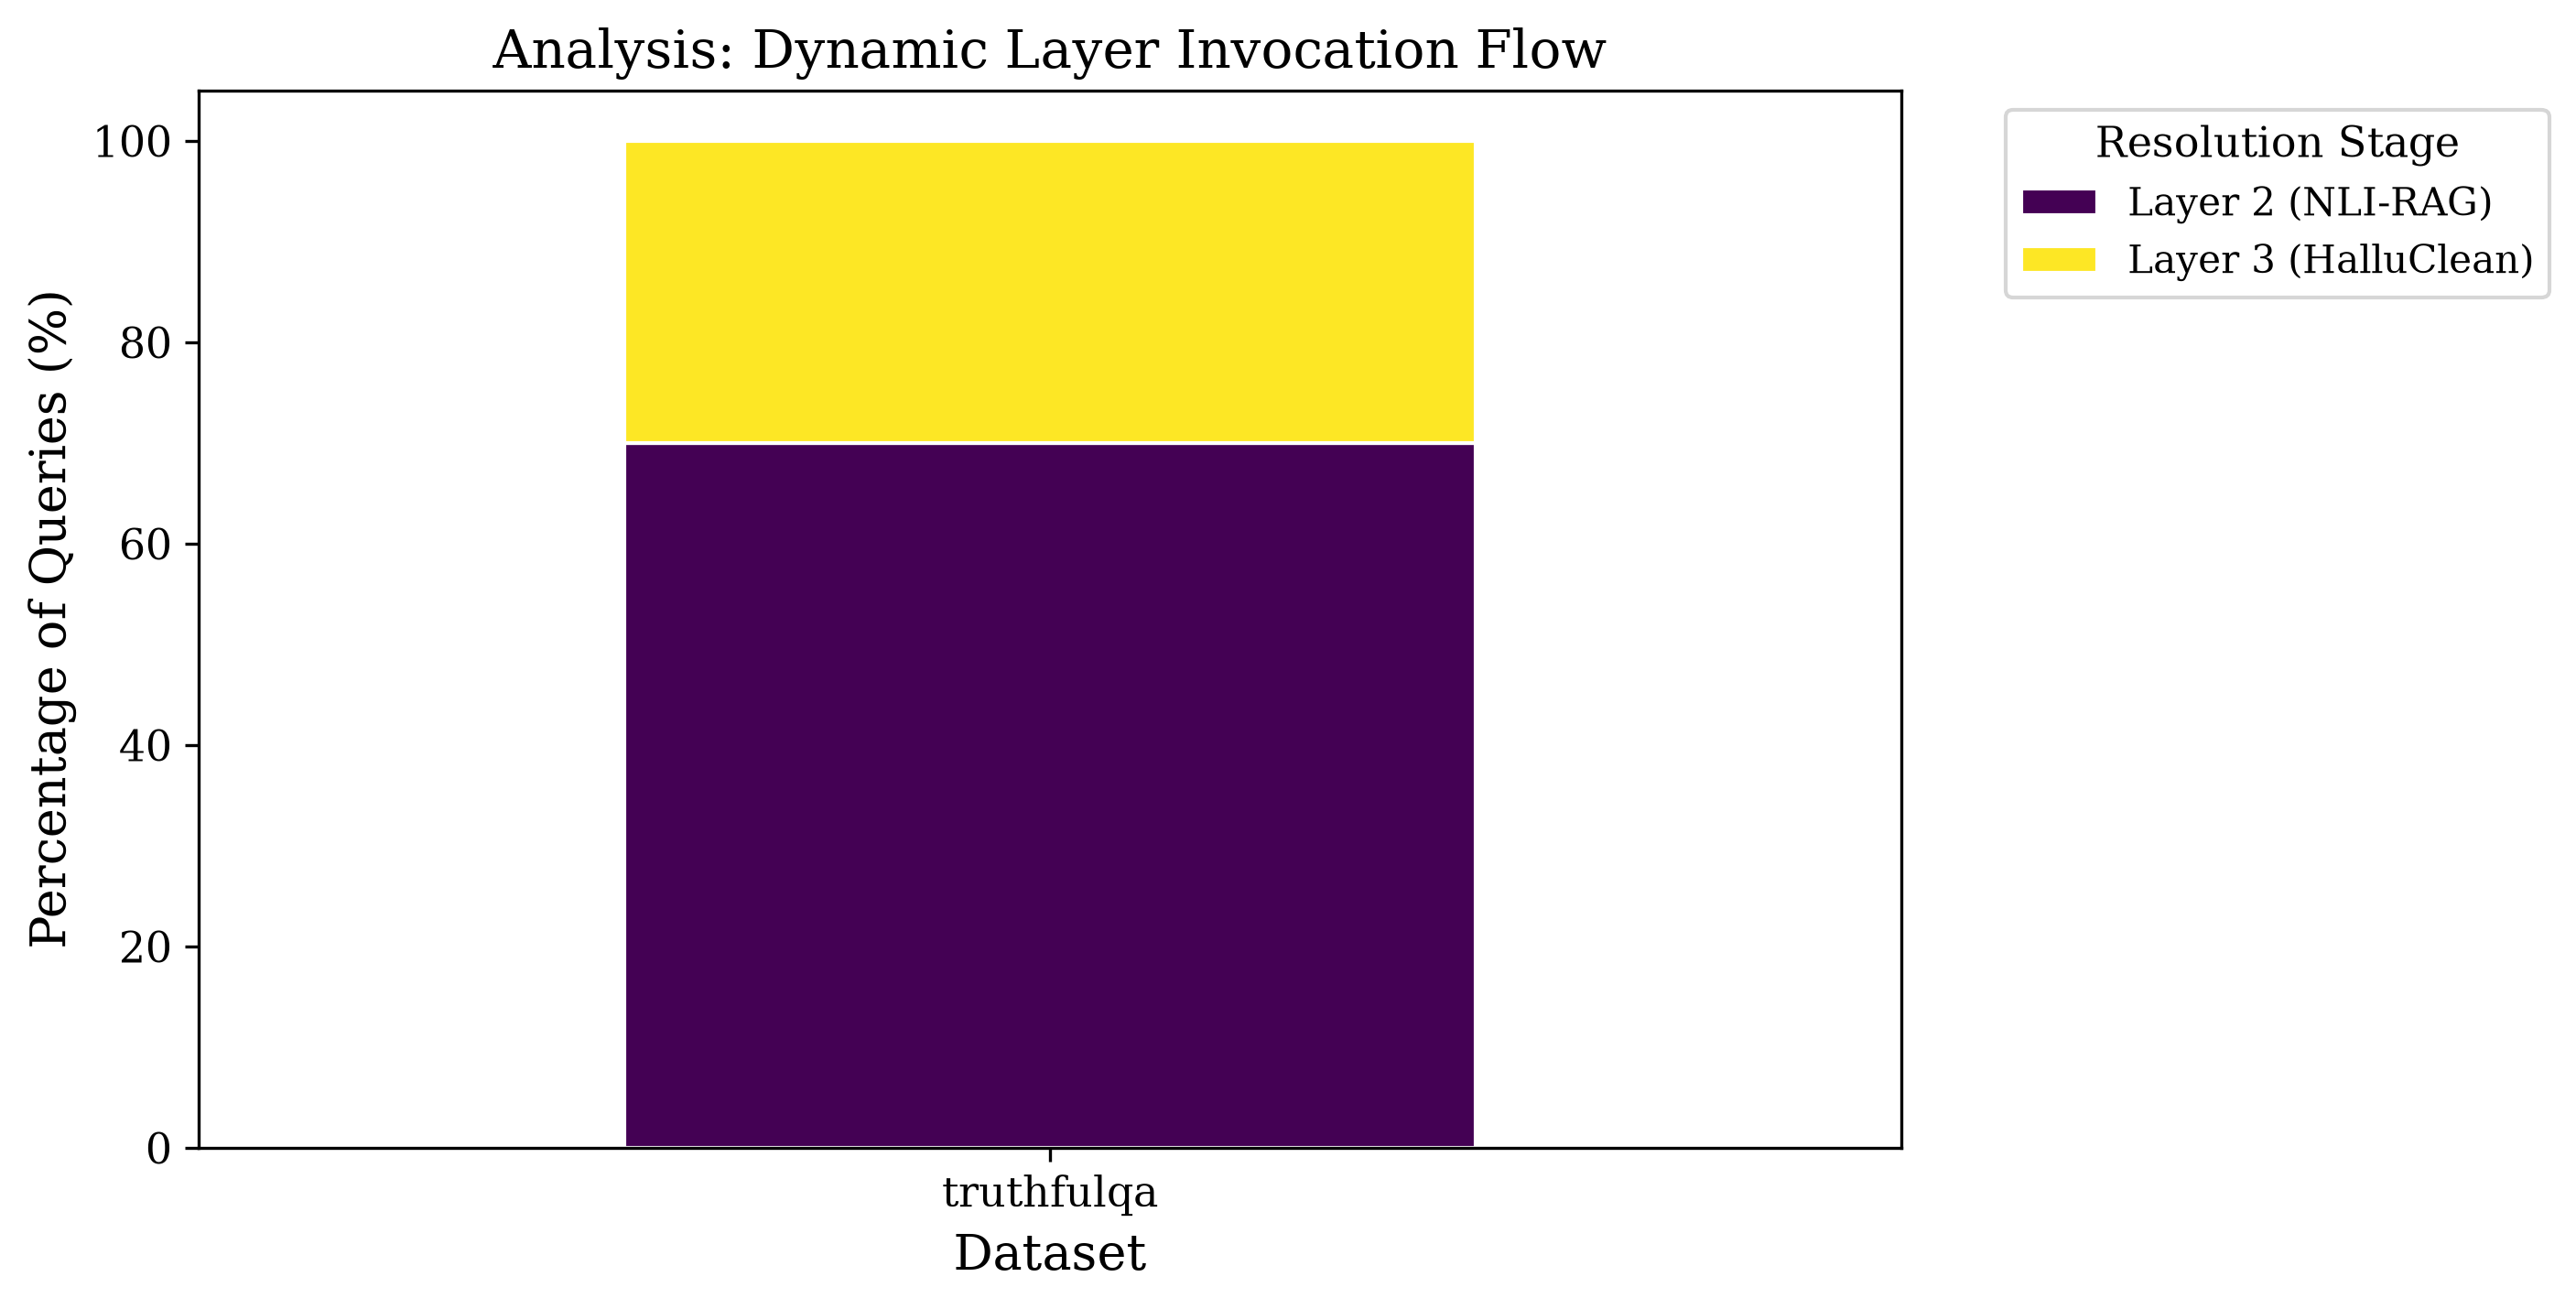


--- IDENTIFIED ERROR PROFILES ---


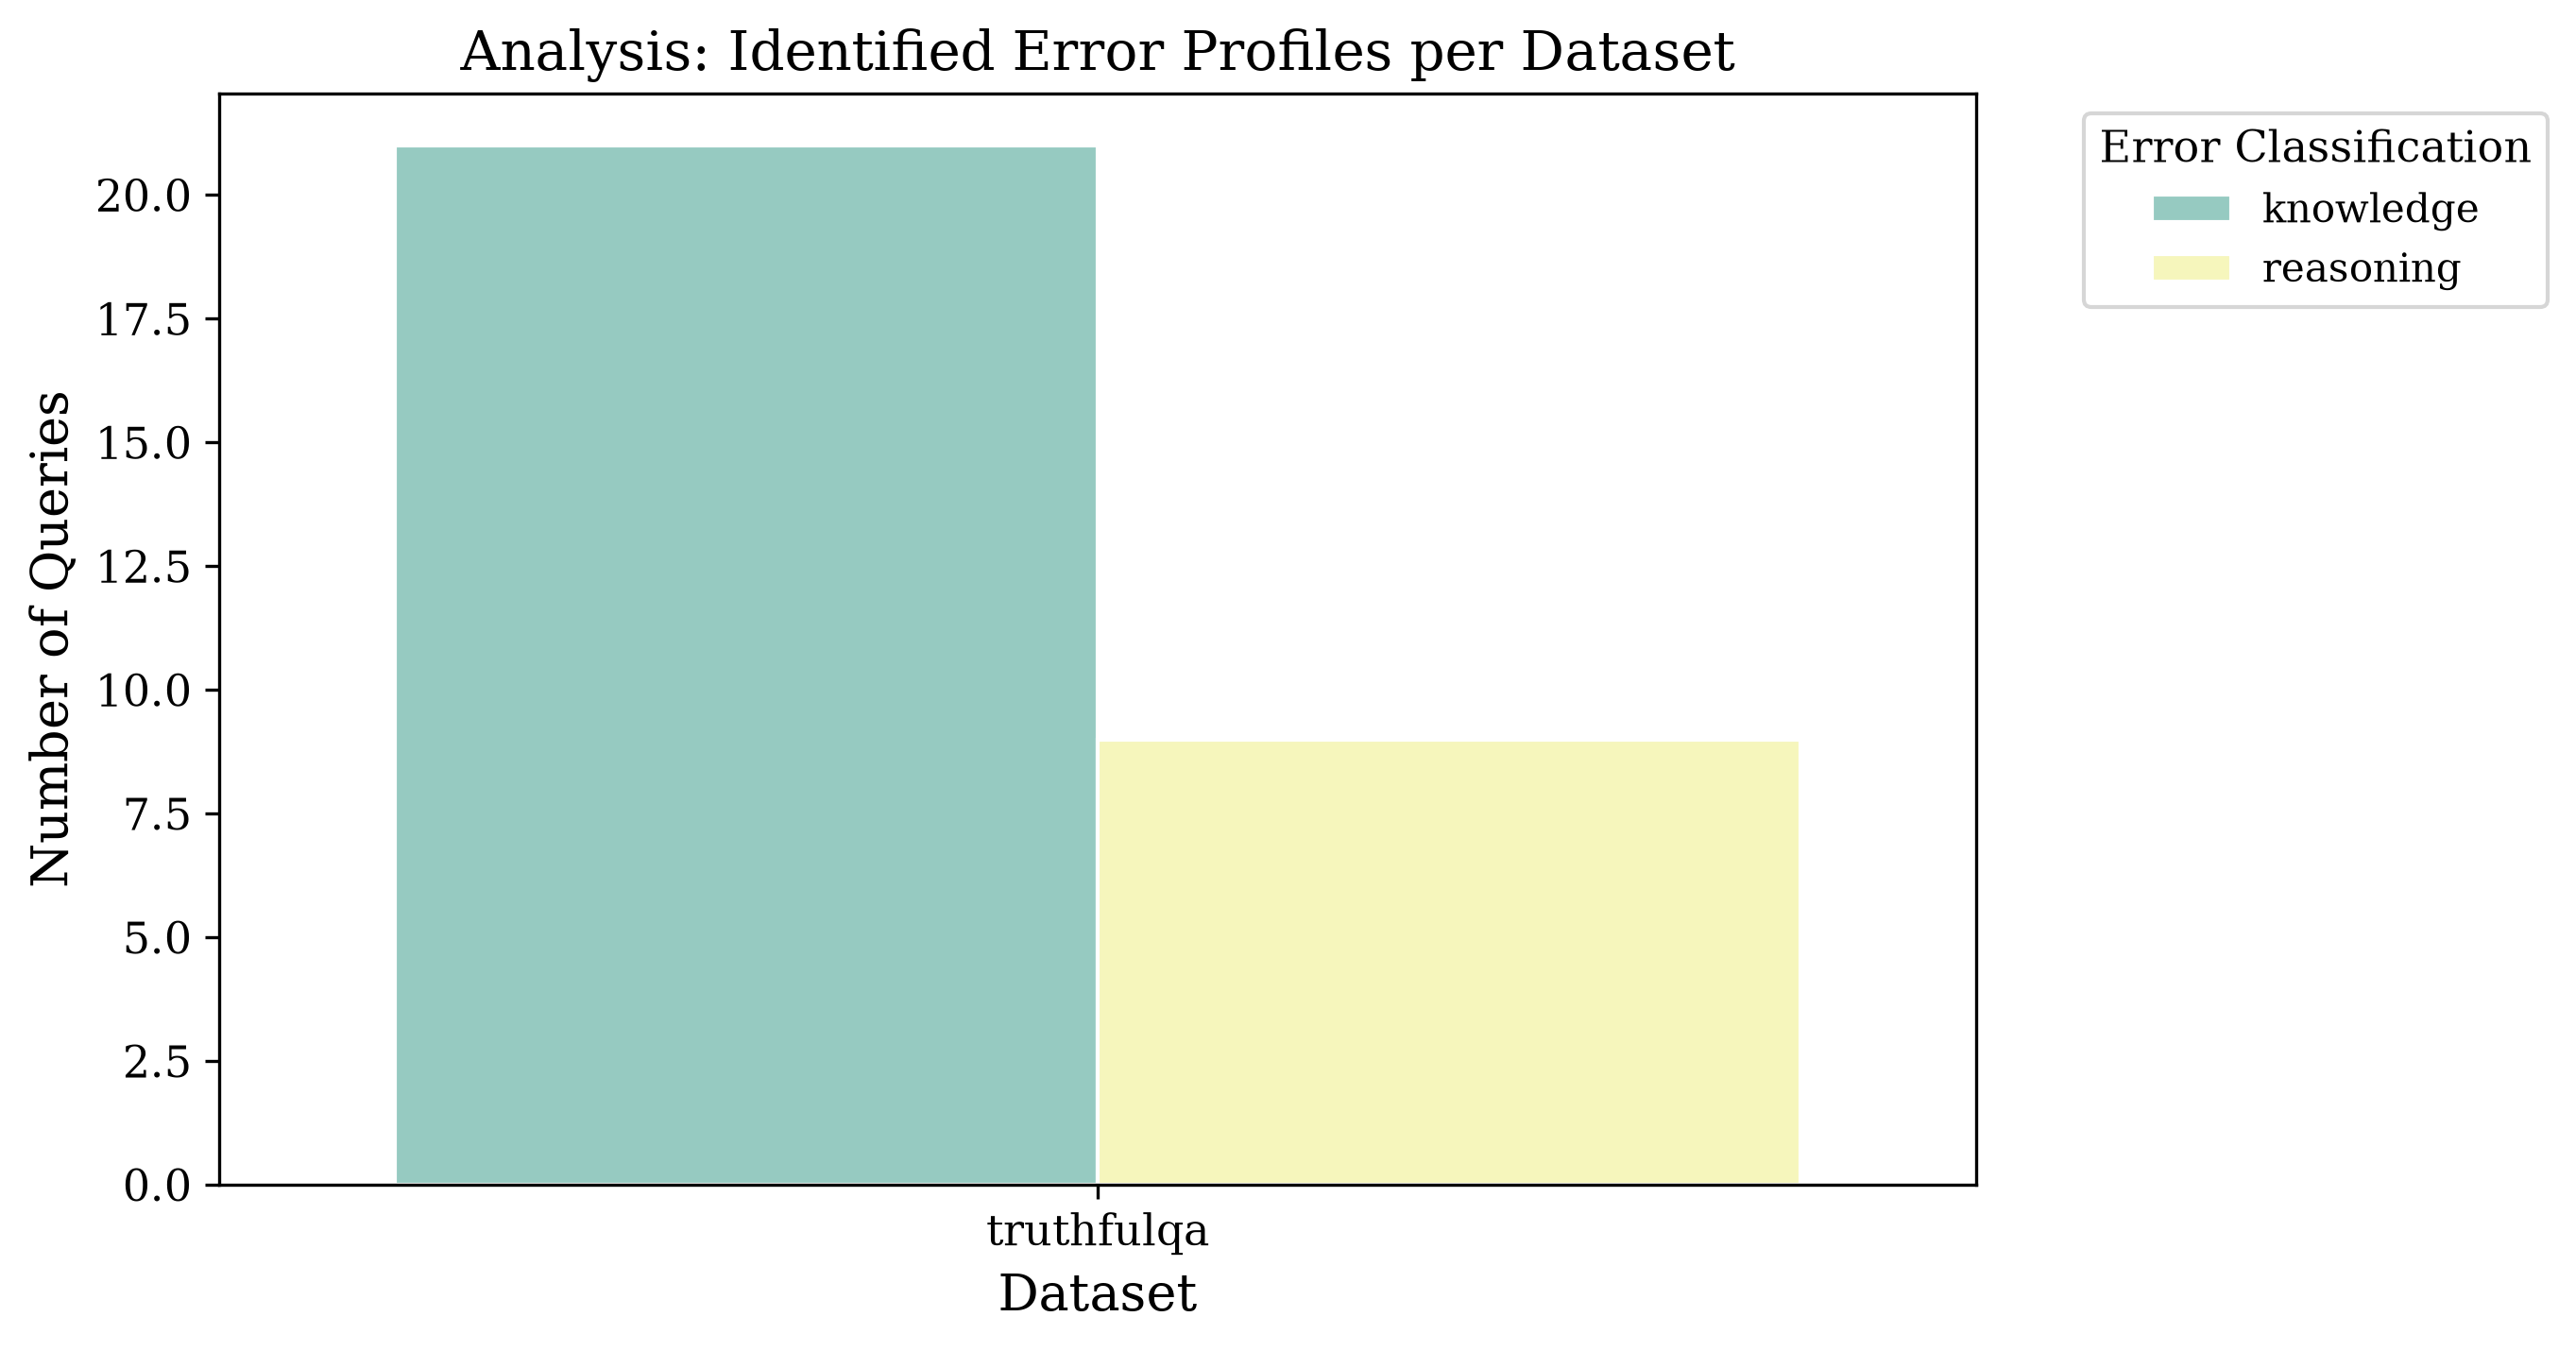


--- SCALABILITY (Latency vs Tokens) ---


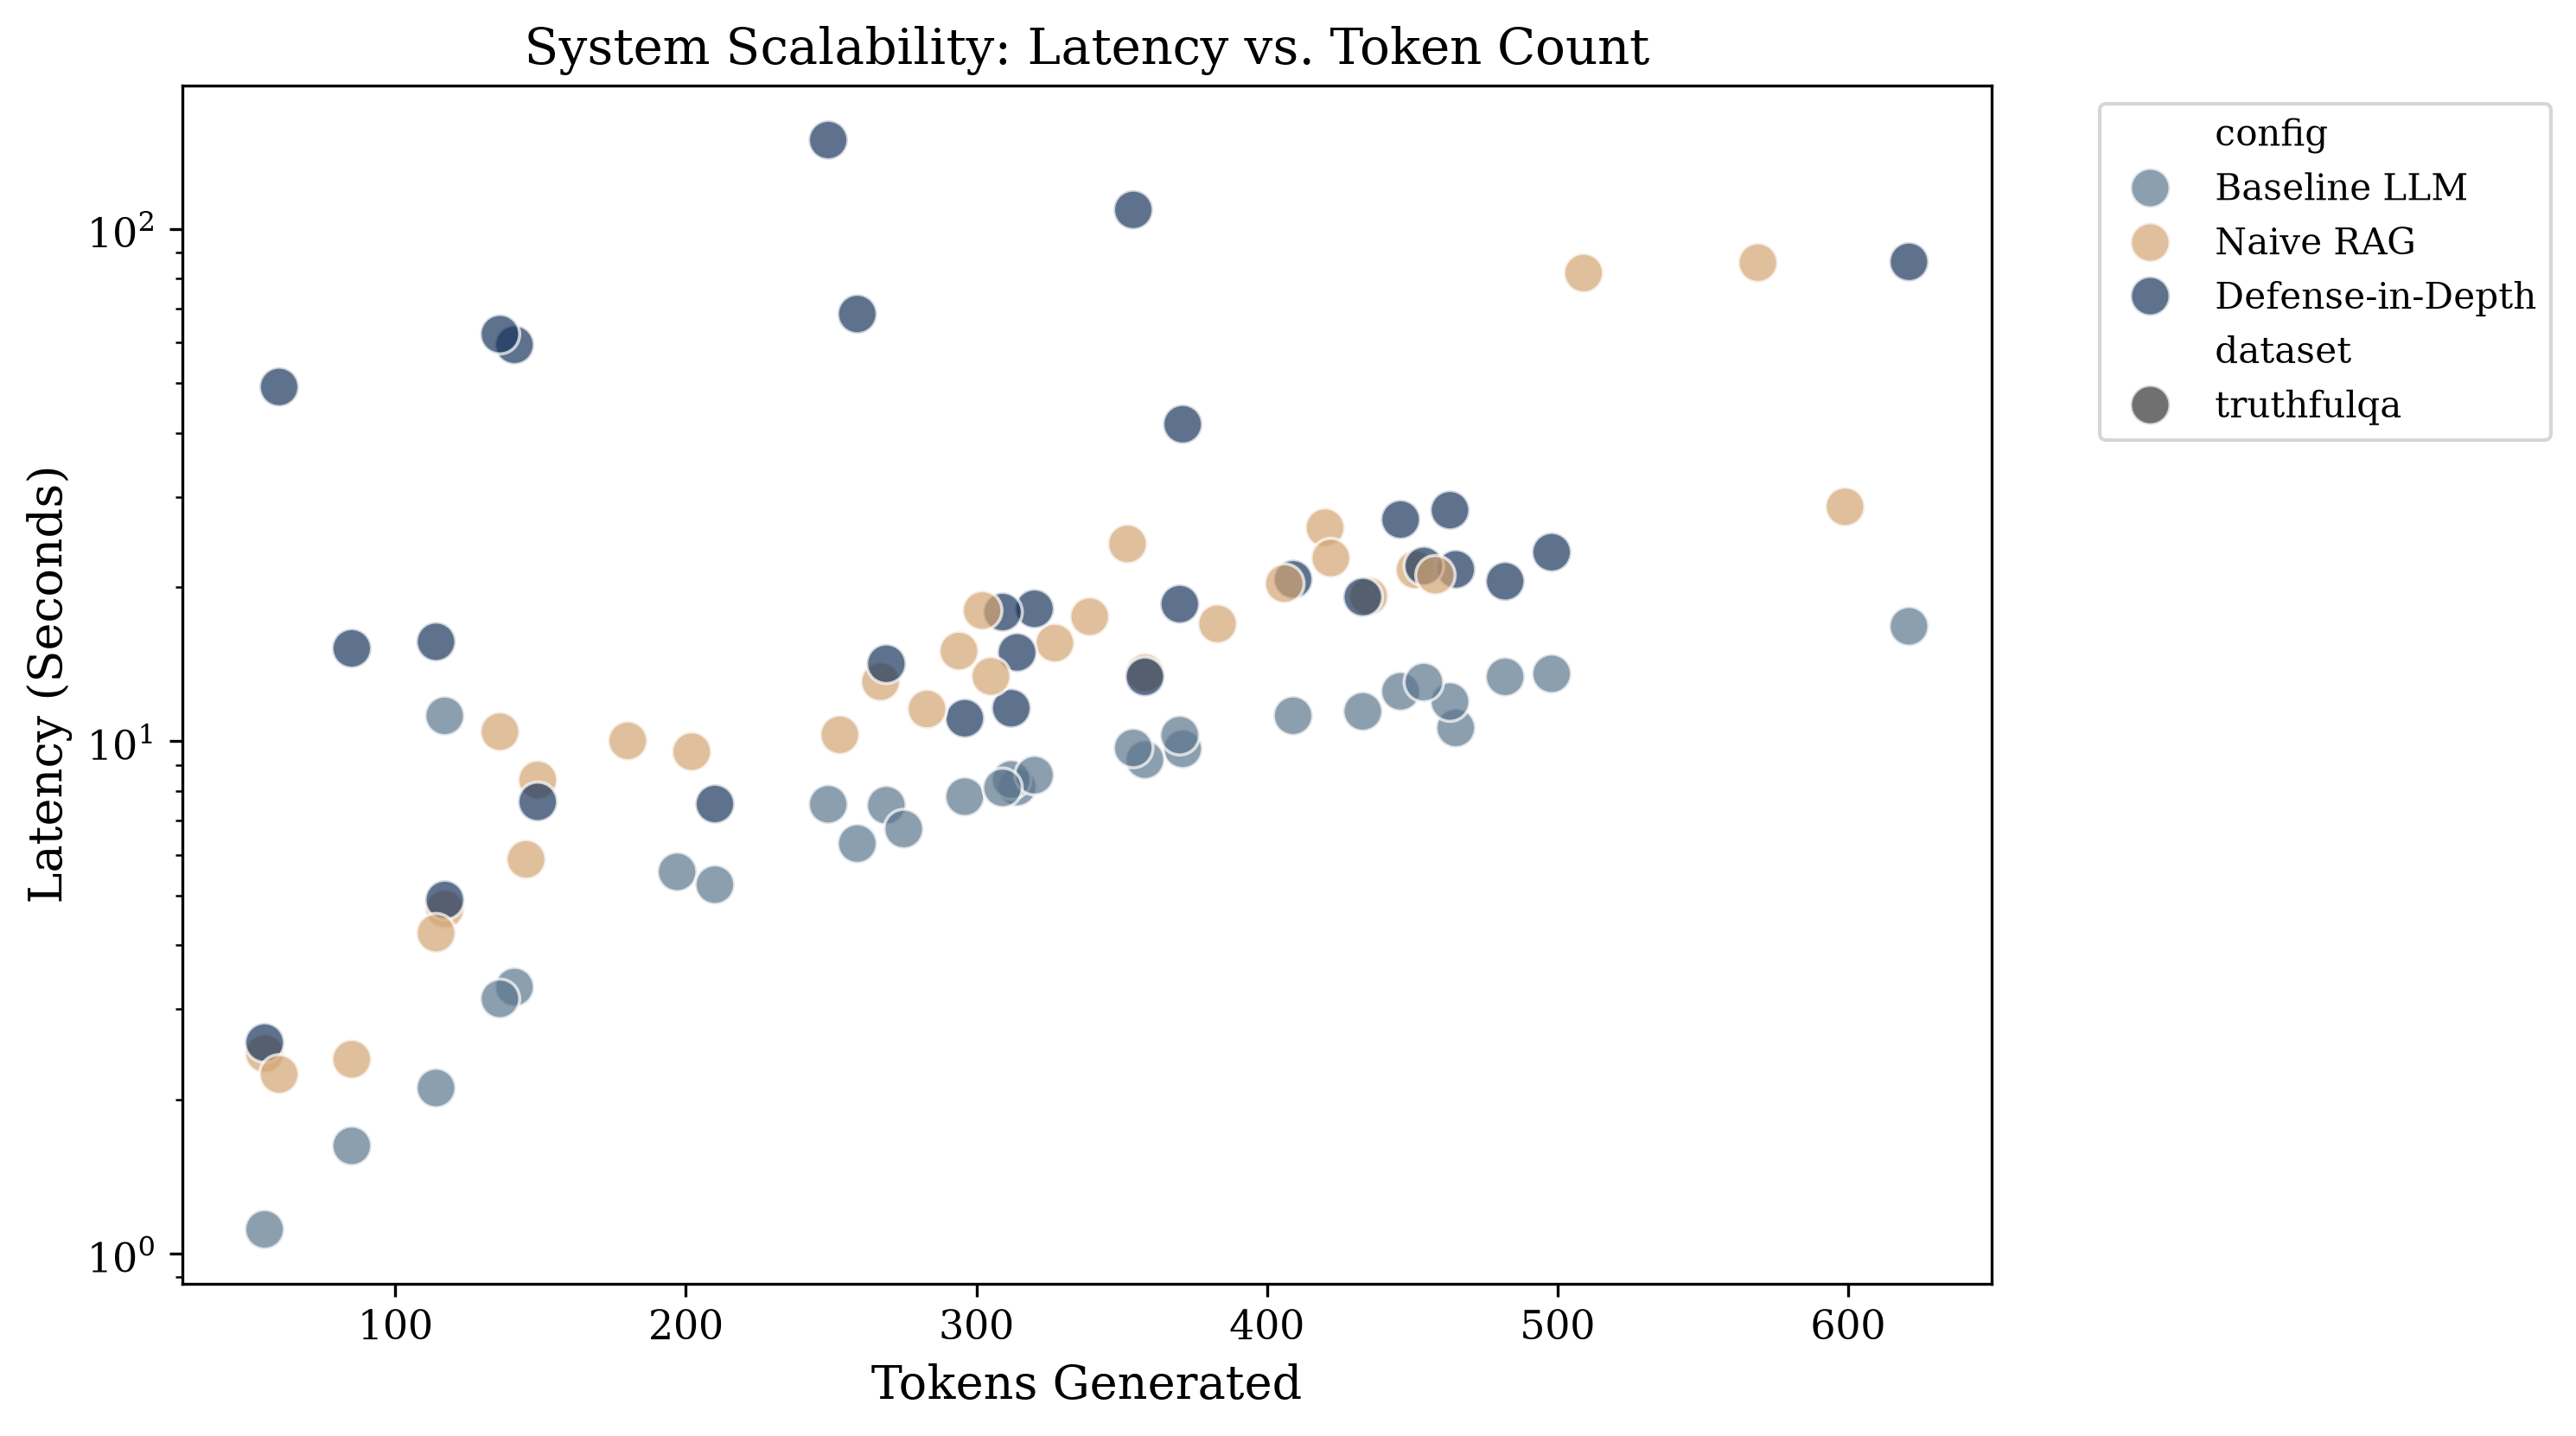

In [2]:
# 1. Run the script to generate all 8 thesis plots
!python evaluation/thesis_plots.py

# 2. Display the generated plots directly in the notebook
from IPython.display import Image, display

print("========== CORE OBJECTIVES ==========\n")

print("--- ACCURACY (Objective 4) ---")
display(Image(filename="evaluation/plots/thesis_accuracy_comparison.png"))

print("\n--- UNCERTAINTY PROBE (Objective 1) ---")
display(Image(filename="evaluation/plots/thesis_entropy_distribution.png"))

print("\n--- TRIAGE ROUTING (Objective 2) ---")
display(Image(filename="evaluation/plots/thesis_routing_piecharts.png"))

print("\n--- COMPUTATIONAL COST (Objective 4) ---")
display(Image(filename="evaluation/plots/thesis_latency_boxplot.png"))

print("\n========== DEEP ANALYSIS ==========\n")

print("--- TOKEN EFFICIENCY ---")
display(Image(filename="evaluation/plots/thesis_token_overhead.png"))

print("\n--- LAYER INVOCATION FLOW ---")
display(Image(filename="evaluation/plots/thesis_layer_invocations.png"))

print("\n--- IDENTIFIED ERROR PROFILES ---")
display(Image(filename="evaluation/plots/thesis_error_types.png"))

print("\n--- SCALABILITY (Latency vs Tokens) ---")
display(Image(filename="evaluation/plots/thesis_latency_scaling.png"))
